# SHAP 步骤一结果

shell运行代码 `python3 interpret_brats.py`

Using device: cuda
Calculating SHAP values for Class 3...
Overlap@0.1 between SHAP and Uncertainty: 0.6755
Result saved to brats_shap_result.png

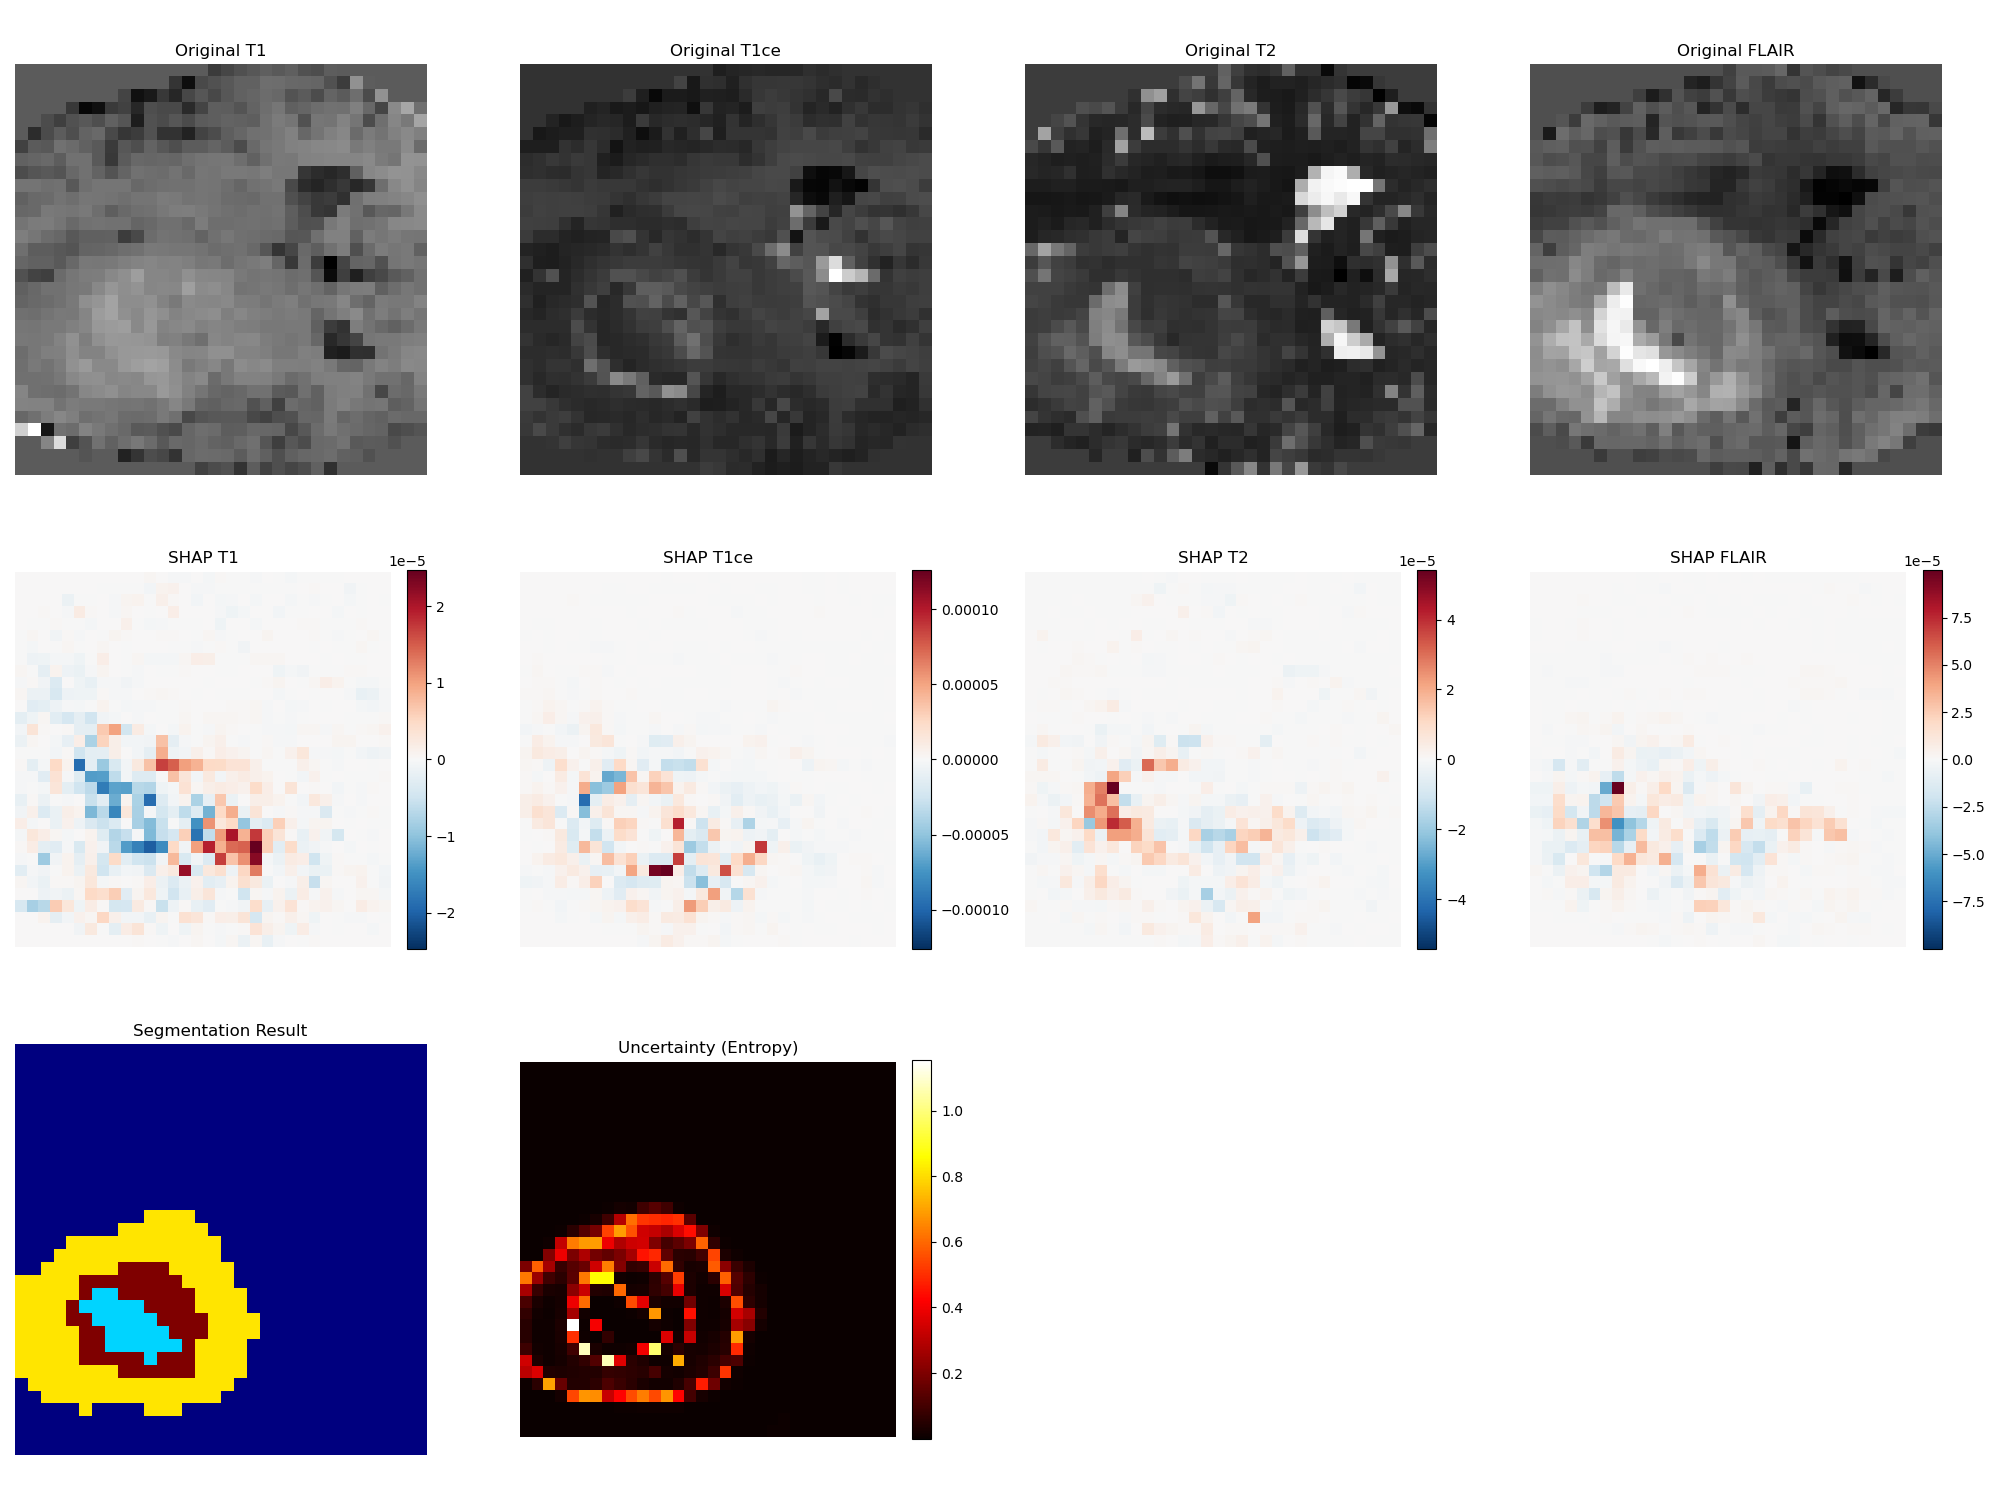

### 1. 颜色代表的含义

热力图使用了 `RdBu_r`（红-蓝）配色方案：

- __红色区域（正贡献）__：代表该位置的像素特&#x5F81;__&#x589E;加&#x4E86;__&#x6A21;型预测为“肿瘤核心（Class 3）”的概率。也就是说，模型认为这些区域的特征是判断肿瘤的关键证据。
- __蓝色区域（负贡献）__：代表该位置的像素特&#x5F81;__&#x964D;低&#x4E86;__&#x6A21;型预测为该类别的概率（或者说这些特征让模型觉得它更像是背景或其他类别）。
- __颜色越深__：代表贡献的强度（Shapley Value 的绝对值）越大。

### 2. 多模态的意义

图中分别展示了 BraTS 的四个模态（T1, T1ce, T2, FLAIR）对应的 SHAP 图：

- 通过对比您可以发现，模型在不同模态上关注的重点不同。例如，在 __T1ce（增强对比 T1）__ 模态上，肿瘤边缘通常会有更明显的红色高亮，因为该模态对增强肿瘤最敏感。
- 这证明了模型确实在利用多模态的互补信息进行决策。

### 3. 与不确定性的关联

我们在控制台输出的 `Overlap@0.1: 0.6755` 进一步量化了这张图的价值：

- 它表示 SHAP 贡献最高的前 10% 区域与模型预测最不确定（熵最高）的区域有 __67.55%__ 的重合。
- 这通常意味着模型在处理复杂的肿瘤边界或异质性区域时，既投入了大量的“注意力”（SHAP 高分），同时也伴随着较高的不确定性。

### 总结

这张图直观地回答了：__“模型在看哪里？”__ 以及 __“每个模态对最终分割结果贡献了多少？”__。它是验证模型是否学到了正确的医学特征（而非过拟合到噪声）的重要工具。
